In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from transformers import AutoTokenizer
import torch

from openTSNE import affinity

In [ ]:
import transformers

transformers.__version__

'4.50.2'

In [ ]:
%load_ext IPython.extensions.autoreload
%autoreload 2

from text_visualizations._cne import (
    NeighborTransformData,
    NeighborTransformIndices,
    FastTensorDataLoader,
)
from text_visualizations.data_stuff import (
    AbstractAndCropDataset,
    MaskedSentenceAbstractDataset,
)

The IPython.extensions.autoreload extension is already loaded. To reload it, use:
  %reload_ext IPython.extensions.autoreload


In [ ]:
import black
import jupyter_black

jupyter_black.load(line_length=79)

In [ ]:
from pathlib import Path


variables_path = Path("../results/variables")
figures_path = Path("../results/figures/tmp")
data_path = Path("../data")

# Imports (general)

In [ ]:
%%time
iclr = pd.read_parquet(
    data_path / "iclr25v2.parquet",
    engine="fastparquet",  # "pyarrow",
)

CPU times: user 187 ms, sys: 83.8 ms, total: 271 ms
Wall time: 1.56 s


# Test

## Toy data

<matplotlib.collections.PathCollection>

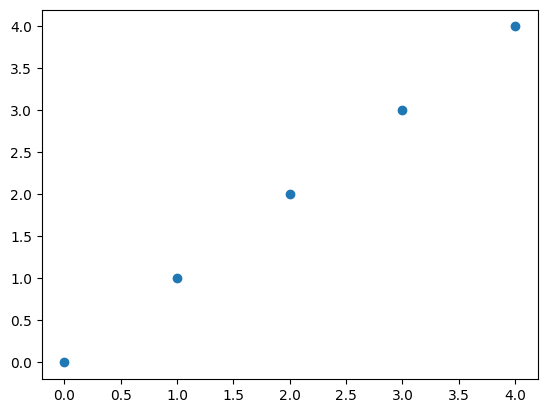

In [ ]:
x=np.arange(5)
plt.scatter(x,x)

In [ ]:
test_data= np.vstack((x,x)).T +1
test_data.shape
print(test_data)

[[1 1]
 [2 2]
 [3 3]
 [4 4]
 [5 5]]


In [ ]:
A = affinity.Uniform(
    test_data,
    verbose=True,
    random_state=42,
    k_neighbors=2,
    symmetrize=False,
)

===> Finding 2 nearest neighbors using exact search using euclidean distance...
   --> Time elapsed: 0.00 seconds


In [ ]:
A_test = A.P.todense()*10
print(A_test)

[[0. 1. 1. 0. 0.]
 [1. 0. 1. 0. 0.]
 [0. 1. 0. 1. 0.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 1. 0.]]


In [ ]:
from scipy.sparse import diags, csr_matrix

ones_diag = diags([1], [0], shape=(A.P.shape[0],A.P.shape[1]), format='csr')  # CSR diagonal matrix of ones
A_plus_one = A.P + ones_diag  # Add matrices (result remains CSR)

In [ ]:
print(A_plus_one.todense())

[[1. 1. 1. 0. 0.]
 [1. 1. 1. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 1. 1. 1.]
 [0. 0. 1. 1. 1.]]


In [ ]:
# if symmetrized
A.P.todense()

matrix([[0.  , 0.1 , 0.05, 0.  , 0.  ],
        [0.1 , 0.  , 0.1 , 0.  , 0.  ],
        [0.05, 0.1 , 0.  , 0.1 , 0.05],
        [0.  , 0.  , 0.1 , 0.  , 0.1 ],
        [0.  , 0.  , 0.05, 0.1 , 0.  ]])

## Dataset and loader

In [ ]:
dataset_test = NeighborTransformData(test_data, A_test,random_state=42)

In [ ]:
import torch

gen = torch.Generator()
gen.manual_seed(42)
training_loader = torch.utils.data.DataLoader(dataset_test, batch_size=2, shuffle=True, generator=gen)

In [ ]:
%%time
dataset_test = NeighborTransformData(test_data, A_test,random_state=42)
training_loader = torch.utils.data.DataLoader(dataset_test, batch_size=2, shuffle=True, generator=gen)

for i, elem in enumerate(training_loader):
    print(elem)

[tensor([[1., 1.],
        [4., 4.]]), tensor([[2., 2.],
        [5., 5.]])]
[tensor([[3., 3.],
        [2., 2.]]), tensor([[4., 4.],
        [1., 1.]])]
[tensor([[5., 5.]]), tensor([[3., 3.]])]
CPU times: user 8.39 ms, sys: 44 μs, total: 8.43 ms
Wall time: 7.53 ms


In [ ]:
%%time

dataloader_test= FastTensorDataLoader(A.P, batch_size=2, shuffle=True, seed=42)

for i, elem in enumerate(dataloader_test):
    print(elem)
    # print(elem[0][0],elem[1][0])
    # print(test_data[elem[0][0]],test_data[elem[1][0]])

(tensor([1, 3], dtype=torch.int32), tensor([0, 2], dtype=torch.int32))
(tensor([0, 4], dtype=torch.int32), tensor([2, 3], dtype=torch.int32))
(tensor([2, 2], dtype=torch.int32), tensor([1, 3], dtype=torch.int32))
(tensor([0, 4], dtype=torch.int32), tensor([1, 2], dtype=torch.int32))
(tensor([1, 3], dtype=torch.int32), tensor([2, 4], dtype=torch.int32))
CPU times: user 7.22 ms, sys: 1.88 ms, total: 9.1 ms
Wall time: 20.5 ms


### Test with tokenizer

In [ ]:
corpus = [
    "aaa aaa",
    "bbb bbb",
    "ccc ccc",
    "ddd ddd",
    "eee eee",
]

In [ ]:
from transformers import AutoTokenizer
model_path = "sentence-transformers/all-mpnet-base-v2"
tokenizer_kwargs = dict(
    max_length=512,
    padding=True,
    truncation=True,
    return_tensors="pt",
)

tokenizer = AutoTokenizer.from_pretrained(model_path)

In [ ]:
tok_output = tokenizer(corpus)
tok_output

{'input_ids': [[0, 13364, 13364, 2], [0, 22865, 2501, 22865, 2501, 2], [0, 10511, 2282, 10511, 2282, 2], [0, 20319, 2098, 20319, 2098, 2], [0, 25216, 2067, 25216, 2067, 2]], 'attention_mask': [[1, 1, 1, 1], [1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1]]}

In [ ]:
tok_output.input_ids

[[0, 13364, 13364, 2],
 [0, 22865, 2501, 22865, 2501, 2],
 [0, 10511, 2282, 10511, 2282, 2],
 [0, 20319, 2098, 20319, 2098, 2],
 [0, 25216, 2067, 25216, 2067, 2]]

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
class NeighborAbstracts(torch.utils.data.Dataset):
    """Returns a pair of neighboring points in the dataset."""
    def __init__(
            self, abstracts, tokenizer, device, neighbor_mat, tokenizer_kwargs=None, random_state=None
    ):

        self.abstracts = abstracts
        self.neighbor_mat = neighbor_mat
        self.rng = np.random.default_rng(random_state)

        if tokenizer_kwargs is None:
            tokenizer_kwargs = dict(
                max_length=512,
                padding=True,
                truncation=True,
                return_tensors="pt",
            )
        
        self.tok_output = tokenizer(
            self.abstracts, **tokenizer_kwargs
        ).to(device)

    def __len__(self):
        return len(self.abstracts)

    def __getitem__(self, i):
        neighs = self.neighbor_mat[i].nonzero()[1]
        nidx = self.rng.choice(neighs)

        item = self.tok_output.input_ids[i]
        item_amask = self.tok_output.attention_mask[i]
        neigh = self.tok_output.input_ids[nidx]
        neigh_amask = self.tok_output.attention_mask[nidx]
        return (item, item_amask), (neigh, neigh_amask)

In [ ]:
import pandas as pd

In [ ]:
%%time
dataset_test = NeighborAbstracts(pd.Series(corpus), tokenizer, device, A_plus_one, random_state=42)
training_loader = torch.utils.data.DataLoader(dataset_test, batch_size=2, shuffle=True, generator=gen)

for i, elem in enumerate(training_loader):
    print(elem)

ValueError: text input must be of type `str` (single example), `List[str]` (batch or single pretokenized example) or `List[List[str]]` (batch of pretokenized examples).

In [ ]:
tok_output.input_ids

[[0, 13364, 13364, 2],
 [0, 22865, 2501, 22865, 2501, 2],
 [0, 10511, 2282, 10511, 2282, 2],
 [0, 20319, 2098, 20319, 2098, 2],
 [0, 25216, 2067, 25216, 2067, 2]]

In [ ]:
A_test

matrix([[0., 1., 1., 0., 0.],
        [1., 0., 1., 0., 0.],
        [0., 1., 0., 1., 0.],
        [0., 0., 1., 0., 1.],
        [0., 0., 1., 1., 0.]])

# Path

In [ ]:
from pathlib import Path
from text_visualizations.config_helpers import parse_args
from datetime import datetime
import yaml

# from train_hyper_sweep import run_hyperparameter_sweep

## set paths
variables_path = Path("../results/variables")
data_path = Path("../data")
configs_path = Path("../configs")

In [ ]:



exp_name = "test"
hyper_sweep_file = "test_hyper_sweep_file"
# Create summary report
saving_path = (
    variables_path
    / Path("sbert")
    / Path("iclr")
    / Path(exp_name + "_" + datetime.now().strftime("%Y%m%d"))
)
saving_path.mkdir(parents=True, exist_ok=True)
summary_path = (
    saving_path / f"sweep_summary_{datetime.now().strftime('%Y%m%d')}.yaml"
)

print(summary_path.resolve())

with open(summary_path, "w") as f:
    yaml.dump(
        {
            # "sweep_config": exp_config_name,
            # "total_experiments": len(param_combinations),
            # "successful_experiments": sum(r["success"] for r in results),
            # "experiment_results": [
            #     {"params": r["params"], "success": r["success"]} for r in results
            # ],
            "hyper_sweep_file": hyper_sweep_file,
        },
        f,
    )

/gpfs01/berens/user/rgonzalesmarquez/phd/text-visualizations/results/variables/sbert/iclr/test_20250508/sweep_summary_20250508.yaml


# New Augmentations

## Abstract + crop

In [ ]:
test_corpus = [
    "The number of publications in biomedicine and life sciences has grown so much that it is difficult to keep track of new scientific works and to have an overview of the evolution of the field as a whole. Here, we present a two-dimensional (2D) map of the entire corpus of biomedical literature, based on the abstract texts of 21 million English articles from the PubMed database. To embed the abstracts into 2D, we used the large lan- guage model PubMedBERT, combined with t-SNE tailored to handle samples of this size. We used our map to study the emergence of the COVID-19 literature, the evolution of the neuroscience discipline, the uptake of machine learning, the distribution of gender imbalance in academic authorship, and the distribution of re- tracted paper mill articles. Furthermore, we present an interactive website that allows easy exploration and will enable further insights and facilitate future research.",
    "The number of publications in biomedicine and life sciences has grown so much that it is difficult to keep track of new scientific works and to have an overview of the evolution of the field as a whole. Here, we present a two-dimensional (2D) map of the entire corpus of biomedical literature, based on the abstract texts of 21 million English articles from the PubMed database. To embed the abstracts into 2D, we used the large lan- guage model PubMedBERT, combined with t-SNE tailored to handle samples of this size. We used our map to study the emergence of the COVID-19 literature, the evolution of the neuroscience discipline, the uptake of machine learning, the distribution of gender imbalance in academic authorship, and the distribution of re- tracted paper mill articles. Furthermore, we present an interactive website that allows easy exploration and will enable further insights and facilitate future research.",
]
len(test_corpus)

2

In [ ]:
abstracts = pd.Series(test_corpus)
abstracts.map(lambda a: a.split("."))

0    [The number of publications in biomedicine and...
1    [The number of publications in biomedicine and...
dtype: object

In [ ]:
for i, sentences in enumerate(abstracts.map(lambda a: a.split("."))):
    print(i)
    print(sentences)

0
['The number of publications in biomedicine and life sciences has grown so much that it is difficult to keep track of new scientific works and to have an overview of the evolution of the field as a whole', ' Here, we present a two-dimensional (2D) map of the entire corpus of biomedical literature, based on the abstract texts of 21 million English articles from the PubMed database', ' To embed the abstracts into 2D, we used the large lan- guage model PubMedBERT, combined with t-SNE tailored to handle samples of this size', ' We used our map to study the emergence of the COVID-19 literature, the evolution of the neuroscience discipline, the uptake of machine learning, the distribution of gender imbalance in academic authorship, and the distribution of re- tracted paper mill articles', ' Furthermore, we present an interactive website that allows easy exploration and will enable further insights and facilitate future research', '']
1
['The number of publications in biomedicine and life s

In [ ]:
model_path = "sentence-transformers/all-mpnet-base-v2"
tokenizer_kwargs = dict(
    max_length=512,
    padding=True,
    truncation=True,
    return_tensors="pt",
)

tokenizer = AutoTokenizer.from_pretrained(model_path)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
dataset = AbstractAndCropDataset(iclr.abstract, tokenizer, device)

In [ ]:
# tests
print(len(dataset.abs_toks[0][0]))
print(len(dataset.abs_toks))
# ==
print(len(dataset.selection_abs_tokenized["input_ids"][0]))
print(len(dataset.selection_abs_tokenized["input_ids"]))
# ==
print(len(dataset))
dataset[0]

172
33527
512
33527
33527


((tensor([    0,  1041,  3526,  3925,  2004,  2265,  1015,  2919,  5583,  2174,
           9848,  6129,  2042,  7649,  2000,  6670,  2001, 19784, 12050,  4087,
           2011,  1041,  2735,  7713,  2012, 23154,  2019,  3235,  1016,  2027,
           3925, 16807,  2010,  1041,  8556,  2990,  1015, 17376,  7713,  2002,
           2023,  3090,  5683,  2012,  3600,  1041,  4357,  2062,  2039,  2689,
           2003,  2000,  2494,  2279,  1014, 25173, 10000,  2011,  2053,  2950,
           1016,     2,     1,     1,     1,     1,     1,     1,     1,     1,
              1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
              1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
              1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
              1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
              1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
              1,     1,     1,     1,   

In [ ]:
training_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    # generator=gen,
)

In [ ]:
for elem in training_loader:
    print(elem)
    break

[[tensor([[    0,  2061,  4689,  ...,     1,     1,     1],
        [    0,  4923,  1014,  ...,     1,     1,     1],
        [    0,  2004,  9466,  ...,     1,     1,     1],
        ...,
        [    0,  2000, 16597,  ...,     1,     1,     1],
        [    0,  2003,  2111,  ...,     1,     1,     1],
        [    0,  2003,  2027,  ...,     1,     1,     1]], device='cuda:0'), tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]], device='cuda:0')], [tensor([[    0, 15716,  1015,  ...,     1,     1,     1],
        [    0, 23978, 15989,  ...,     1,     1,     1],
        [    0,  2788,  4087,  ...,     1,     1,     1],
        ...,
        [    0, 16187,  9017,  ...,     1,     1,     1],
        [    0,  8390,  2393,  ...,     1,     1,     1],
        [    0,  2000,  2201,  ...,     1,     1,     1]], device='cuda:0'), 

## Abstract with two different masks

In [ ]:
test_corpus = [
    "The number of publications in biomedicine and life sciences has grown so much that it is difficult to keep track of new scientific works and to have an overview of the evolution of the field as a whole. Here, we present a two-dimensional (2D) map of the entire corpus of biomedical literature, based on the abstract texts of 21 million English articles from the PubMed database. To embed the abstracts into 2D, we used the large lan- guage model PubMedBERT, combined with t-SNE tailored to handle samples of this size. We used our map to study the emergence of the COVID-19 literature, the evolution of the neuroscience discipline, the uptake of machine learning, the distribution of gender imbalance in academic authorship, and the distribution of re- tracted paper mill articles. Furthermore, we present an interactive website that allows easy exploration and will enable further insights and facilitate future research.",
    "The number of publications in biomedicine and life sciences has grown so much that it is difficult to keep track of new scientific works and to have an overview of the evolution of the field as a whole. Here, we present a two-dimensional (2D) map of the entire corpus of biomedical literature, based on the abstract texts of 21 million English articles from the PubMed database. To embed the abstracts into 2D, we used the large lan- guage model PubMedBERT, combined with t-SNE tailored to handle samples of this size. We used our map to study the emergence of the COVID-19 literature, the evolution of the neuroscience discipline, the uptake of machine learning, the distribution of gender imbalance in academic authorship, and the distribution of re- tracted paper mill articles. Furthermore, we present an interactive website that allows easy exploration and will enable further insights and facilitate future research.",
]
len(test_corpus)

2

In [ ]:
abstracts = pd.Series(test_corpus)
abstracts.map(lambda a: [s.strip() + "." for s in a.split(".") if s.strip()])[
    0
]

['The number of publications in biomedicine and life sciences has grown so much that it is difficult to keep track of new scientific works and to have an overview of the evolution of the field as a whole.',
 'Here, we present a two-dimensional (2D) map of the entire corpus of biomedical literature, based on the abstract texts of 21 million English articles from the PubMed database.',
 'To embed the abstracts into 2D, we used the large lan- guage model PubMedBERT, combined with t-SNE tailored to handle samples of this size.',
 'We used our map to study the emergence of the COVID-19 literature, the evolution of the neuroscience discipline, the uptake of machine learning, the distribution of gender imbalance in academic authorship, and the distribution of re- tracted paper mill articles.',
 'Furthermore, we present an interactive website that allows easy exploration and will enable further insights and facilitate future research.']

In [ ]:
abstracts = pd.Series(test_corpus)
abstracts.map(lambda a: a.split("."))[0]

['The number of publications in biomedicine and life sciences has grown so much that it is difficult to keep track of new scientific works and to have an overview of the evolution of the field as a whole',
 ' Here, we present a two-dimensional (2D) map of the entire corpus of biomedical literature, based on the abstract texts of 21 million English articles from the PubMed database',
 ' To embed the abstracts into 2D, we used the large lan- guage model PubMedBERT, combined with t-SNE tailored to handle samples of this size',
 ' We used our map to study the emergence of the COVID-19 literature, the evolution of the neuroscience discipline, the uptake of machine learning, the distribution of gender imbalance in academic authorship, and the distribution of re- tracted paper mill articles',
 ' Furthermore, we present an interactive website that allows easy exploration and will enable further insights and facilitate future research',
 '']

In [ ]:
model_path = "sentence-transformers/all-mpnet-base-v2"
tokenizer_kwargs = dict(
    max_length=512,
    padding=True,
    truncation=True,
    return_tensors="pt",
    return_special_tokens_mask=True,
)

tokenizer = AutoTokenizer.from_pretrained(model_path)

In [ ]:
model_path = "microsoft/mpnet-base"
tokenizer = AutoTokenizer.from_pretrained(model_path)
tokenizer.convert_ids_to_tokens(103)

'[unused98]'

In [ ]:
model_paths = [
    "bert-base-uncased",
    "microsoft/mpnet-base",
    "sentence-transformers/all-mpnet-base-v2",
    "allenai/scibert_scivocab_uncased",
    "allenai/specter",
    "malteos/scincl",
    "princeton-nlp/unsup-simcse-bert-base-uncased",
    "johngiorgi/declutr-base",
    "johngiorgi/declutr-sci-base",
    # "allenai/specter2_base",
]
for model_path in model_paths:
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    print((model_path))
    print(tokenizer)
    print(
        tokenizer.mask_token_id
        if hasattr(tokenizer, "mask_token_id")
        else "NO ATTR"
    )
    print("---------------------------------------")

bert-base-uncased
BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)
103
---------------------------------------
microsoft/mpnet-base
MPNetTokenizerFast(name_or_path='microsoft/

ImportError: 
 requires the protobuf library but it was not found in your environment. Checkout the instructions on the
installation page of its repo: https://github.com/protocolbuffers/protobuf/tree/master/python#installation and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.


In [ ]:
tokenizer("<mask>", add_special_tokens=False)["input_ids"][0]

30526

In [ ]:
3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
104: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
30526: AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, normalized=False, special=True),
}

In [ ]:
3: AddedToken("<unk>"
104: AddedToken("[UNK]"
30526: AddedToken("<mask>"


In [ ]:
tokenizer

MPNetTokenizerFast(name_or_path='sentence-transformers/all-mpnet-base-v2', vocab_size=30527, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '[UNK]', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	104: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	30526: AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, norma

In [ ]:
output = tokenizer(test_corpus, **tokenizer_kwargs)

In [ ]:
period_token_id = tokenizer(".", add_special_tokens=False)["input_ids"][0]
period_token_id

1016

In [ ]:
output.input_ids
# [
output.special_tokens_mask
# ]  # [0]  # ["attention_mask"]  # .keys()  # ["special_tokens_mask"]

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
text = tokenizer.decode(token_ids, skip_special_tokens=True)

In [ ]:
a = np.zeros(10)
a[3:6] = 1
print(a)

[0. 0. 0. 1. 1. 1. 0. 0. 0. 0.]


In [ ]:
a = output.special_tokens_mask[0]
a[3:6] = 2
a

tensor([1, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

### Test class

In [ ]:
test_corpus = [
    "The number of publications in biomedicine and life sciences has grown so much that it is difficult to keep track of new scientific works and to have an overview of the evolution of the field as a whole. Here, we present a two-dimensional (2D) map of the entire corpus of biomedical literature, based on the abstract texts of 21 million English articles from the PubMed database. To embed the abstracts into 2D, we used the large lan- guage model PubMedBERT, combined with t-SNE tailored to handle samples of this size. We used our map to study the emergence of the COVID-19 literature, the evolution of the neuroscience discipline, the uptake of machine learning, the distribution of gender imbalance in academic authorship, and the distribution of re- tracted paper mill articles. Furthermore, we present an interactive website that allows easy exploration and will enable further insights and facilitate future research.",
    "The number of publications in biomedicine and life sciences has grown so much that it is difficult to keep track of new scientific works and to have an overview of the evolution of the field as a whole. Here, we present a two-dimensional (2D) map of the entire corpus of biomedical literature, based on the abstract texts of 21 million English articles from the PubMed database. To embed the abstracts into 2D, we used the large lan- guage model PubMedBERT, combined with t-SNE tailored to handle samples of this size. We used our map to study the emergence of the COVID-19 literature, the evolution of the neuroscience discipline, the uptake of machine learning, the distribution of gender imbalance in academic authorship, and the distribution of re- tracted paper mill articles. Furthermore, we present an interactive website that allows easy exploration and will enable further insights and facilitate future research.",
]
len(test_corpus)

2

In [ ]:
model_path = "sentence-transformers/all-mpnet-base-v2"
tokenizer_kwargs = dict(
    max_length=512,
    padding=True,
    truncation=True,
    return_tensors="pt",
)

tokenizer = AutoTokenizer.from_pretrained(model_path)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
dataset = MaskedSentenceAbstractDataset(iclr.abstract, tokenizer, device)

In [ ]:
dataset[0]

((tensor([    0,  1041,  3526,  3925,  2004,  2265,  1015,  2919,  5583,  2174,
           9848,  6129,  2042,  7649,  2000,  6670,  2001, 19784, 12050,  4087,
           2011,  1041,  2735,  7713,  2012, 23154,  2019,  3235,  1016,  2027,
           3925, 16807,  2010,  1041,  8556,  2990,  1015, 17376,  7713,  2002,
           2023,  3090,  5683,  2012,  3600,  1041,  4357,  2062,  2039,  2689,
           2003,  2000,  2494,  2279,  1014, 25173, 10000,  2011,  2053,  2950,
           1016, 30526, 30526, 30526, 30526, 30526, 30526, 30526, 30526, 30526,
          30526, 30526, 30526, 30526, 30526, 30526, 30526, 30526, 30526, 30526,
          30526, 30526, 30526, 30526, 30526, 30526, 30526, 30526, 30526, 30526,
          30526, 30526, 30526, 30526, 30526, 30526, 30526, 30526, 30526, 30526,
          30526, 30526, 30526, 30526, 30526, 30526, 30526, 30526, 30526, 30526,
          30526, 30526, 30526, 30526, 30526, 30526, 30526, 30526, 30526, 30526,
          30526, 30526, 30526, 30526, 30

In [ ]:
training_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    # generator=gen,
)

In [ ]:
for elem in training_loader:
    print(elem)
    break

[[tensor([[    0, 30526, 30526,  ...,     1,     1,     1],
        [    0,  2100,  2899,  ...,     1,     1,     1],
        [    0,  2061,  2560,  ...,     1,     1,     1],
        ...,
        [    0,  5541,  1015,  ...,     1,     1,     1],
        [    0,  2003,  2120,  ...,     1,     1,     1],
        [    0, 30526, 30526,  ...,     1,     1,     1]], device='cuda:0'), tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]], device='cuda:0')], [tensor([[    0, 17970, 10815,  ...,     1,     1,     1],
        [    0,  2100,  2899,  ...,     1,     1,     1],
        [    0,  2061,  2560,  ...,     1,     1,     1],
        ...,
        [    0,  5541,  1015,  ...,     1,     1,     1],
        [    0,  2003,  2120,  ...,     1,     1,     1],
        [    0,  2000, 24398,  ...,     1,     1,     1]], device='cuda:0'), 